In [1]:
import cudaq
import time

######################### JENGA ##################################
def pce_loss_function(params):
    # 1. Measure all 60 Pauli expectation values

    
    @cudaq.kernel
    def qc(n: int, variable_list: list[float], pauli: list[int], t: int):
        qubits = cudaq.qvector(n)
        
        for i in range(n):
            h(qubits[i])
    
        for l in range(len(variable_list)//15):
    
            for i in range(n):
                ry(variable_list[15*l+i], qubits[i])
                rz(variable_list[15*l+5+i], qubits[i])
                
                h(qubits[i])
                
            for i in range(n):
                if i != n-1:
                    cx(qubits[i], qubits[i+1])
                    rz(variable_list[15*l+10+i], qubits[i+1])
                    cx(qubits[i], qubits[i+1])
                else:
                    cx(qubits[i], qubits[0])
                    rz(variable_list[15*l+10+i], qubits[i])
                    cx(qubits[i], qubits[0])
                
    
        for i in range(n):
            if pauli[n*t+i] == 0:
                h(qubits[i])
            elif pauli[n*t+i] == 1:
                sdg(qubits[i])
                h(qubits[i])
                
        mz(qubits)
    
    n = 60 
    num_qubits = 5
    shots_var = 100000
    runs = 1
    
    variables = params
    
    string_list = []
    data = []
    for t in range(len(pauli_list)):
        result = cudaq.sample(qc, num_qubits, variables, pauli_flat, t, shots_count=shots_var)
        data += [list(result.items())]
    
    
    E_list = []
    for i in range(len(pauli_list)):
        E = 0
        mult = 1
        for w in range(len(data[i])):
            for j in data[i][w][0]:
                if j == "0":
                    mult *= -1
            
            E += mult*data[i][w][1]/shots_var
        E_list += [E]

    
    # 2. Apply tanh relaxation

    
    alpha = 6.0
    beta = 15.0
    x_tilde = [np.tanh(alpha * exp) for exp in E_list]
    
    
    # 3. Compute LABS loss
    N = len(x_tilde)
    loss = 0.0

    # Autocorrelation energy term
    for ell in range(1, N):
        for i in range(N - ell):
            loss += (x_tilde[i] * x_tilde[i+ell])**2
    
    # Regularization term
    loss -= beta * sum(x**2 for x in x_tilde)
    
    return loss

In [9]:
import numpy as np

a = pce_loss_function([1,2,1,1,1, 2,1,2,2,2, 3,2,3,3,3, 12,11,12,12,12, 22,21,22,22,22, 32,31,32,32, 32])

print(a)

-34.22639180182807


In [8]:
import random
n=60
def random_pauli_string(n):
    paulis = ['X', 'Y', 'Z']
    return ''.join(random.choice(paulis) for _ in range(n))


pauli_list = []
while len(pauli_list) != n:
    pauli = random_pauli_string(5)
    if pauli in pauli_list:
        3
    else:
        pauli_list += [pauli]

pauli_flat = []
for i in pauli_list:
    for j in i:
        if j == "X":
            pauli_flat += [0]
        elif j == "Y":
            pauli_flat += [1]
        else:
            pauli_flat += [2]

print(pauli_list)
print(pauli_flat)

['YZYYY', 'XXYZZ', 'XYYZZ', 'ZZYZX', 'ZXZZZ', 'ZYZZZ', 'ZYXYZ', 'XXXZY', 'YYZXY', 'YZZXY', 'YXZZZ', 'ZYXXY', 'XXYYZ', 'ZZZZY', 'YXXYX', 'YYYXZ', 'ZYYYY', 'XZYYY', 'ZXXYY', 'XZZYY', 'YYYXY', 'YXZXX', 'ZZZXX', 'XYYXZ', 'XXXZZ', 'XZYZX', 'YZXXZ', 'XYYYY', 'XYXZX', 'ZYYXY', 'ZZZZX', 'ZXZYX', 'YZXXY', 'ZZYXX', 'ZYZZX', 'ZZXXY', 'XXXXZ', 'ZZZXZ', 'YZYZZ', 'YZXZY', 'YXZYY', 'ZXYXY', 'YYZXX', 'XXZXZ', 'XXXYY', 'ZYZXX', 'YYXXZ', 'YXYYZ', 'ZZYZY', 'ZXZXZ', 'YXXZZ', 'ZZYYZ', 'YYYXX', 'YZZZX', 'XYZZY', 'YZXZZ', 'ZZZYX', 'XYZXY', 'ZXYYZ', 'XYXYY']
[1, 2, 1, 1, 1, 0, 0, 1, 2, 2, 0, 1, 1, 2, 2, 2, 2, 1, 2, 0, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 0, 1, 2, 0, 0, 0, 2, 1, 1, 1, 2, 0, 1, 1, 2, 2, 0, 1, 1, 0, 2, 2, 2, 2, 1, 0, 0, 1, 0, 0, 1, 1, 2, 2, 2, 2, 2, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 2, 2, 1, 1, 1, 1, 0, 2, 1, 1, 1, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 1, 1, 1, 0, 1, 1, 0, 2, 0, 0, 2, 2, 2, 0, 0, 0, 1, 1, 0, 2, 0, 0, 0, 2, 2, 0, 2, 1, 2, 0, 1, 2, 0, 0, 2, 0, 1, 1, 1, 1, 0, 1, 0, 2, 0, 2, 1, 1, 0, 1, 2, 2, 2,

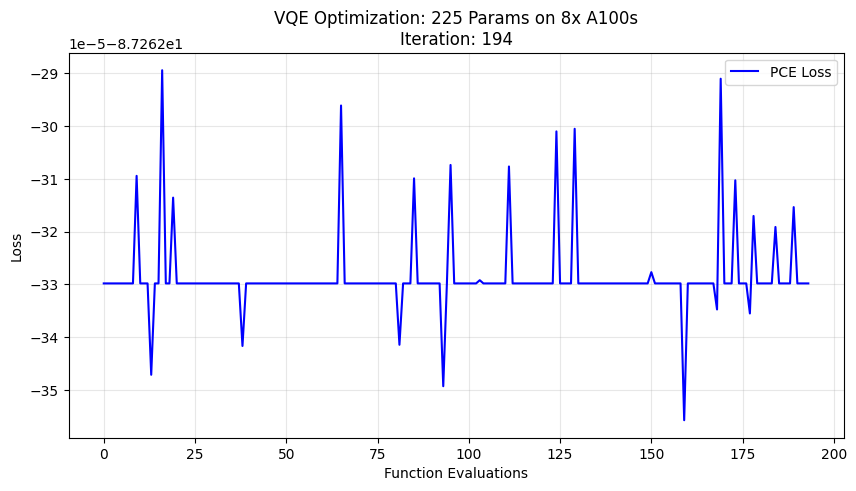

In [ ]:
import cudaq
from cudaq import spin
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import clear_output

# 1. Target the 8x A100 GPUs
cudaq.set_target("nvidia-mqpu")

# 2. Setup Problem Dimensions
num_qubits = 5
num_params = 225
num_paulis = 60
layers = num_params // 15 # 15 layers

# --- ORIGINAL KERNEL (Scaled to 15 layers / 225 params) ---
@cudaq.kernel
def qc_ansatz(n: int, variable_list: list[float]):
    qubits = cudaq.qvector(n)
    for i in range(n):
        h(qubits[i])

    # Dynamic layers based on parameter count
    for l in range(len(variable_list) // 15):
        offset = l * 15
        for i in range(n):
            ry(variable_list[offset + i], qubits[i])
            rz(variable_list[offset + 5 + i], qubits[i])
            h(qubits[i])
                
        for i in range(n):
            if i != n - 1:
                cx(qubits[i], qubits[i + 1])
                rz(variable_list[offset + 10 + i], qubits[i + 1])
                cx(qubits[i], qubits[i + 1])
            else:
                cx(qubits[i], qubits[0])
                rz(variable_list[offset + 10 + i], qubits[i])
                cx(qubits[i], qubits[0])

# --- HELPER: CONVERT STRINGS TO SPIN OPS ---
def get_cudaq_ops(pauli_list):
    ops = []
    for p_str in pauli_list:
        op = spin.identity(num_qubits)
        for i, s in enumerate(p_str):
            if s == 'X': op *= spin.x(i)
            elif s == 'Y': op *= spin.y(i)
            elif s == 'Z': op *= spin.z(i)
        ops.append(op)
    return ops

# --- LOSS FUNCTION CLASS (To track history for plotting) ---
class JengaOptimizer:
    def __init__(self, pauli_ops):
        self.pauli_ops = pauli_ops
        self.loss_history = []

    def pce_loss(self, params):
        # 1. Parallel Measurement on 8 GPUs
        # This executes 60 Pauli measurements simultaneously across the cluster
        futures = [cudaq.observe_async(qc_ansatz, op, num_qubits, params) for op in self.pauli_ops]
        E_list = [f.get().expectation() for f in futures]

        # 2. Tanh Relaxation (Original Logic)
        alpha, beta = 6.0, 15.0
        x_tilde = np.tanh(alpha * np.array(E_list))
        
        # 3. LABS Loss (Original Logic)
        N = len(x_tilde)
        loss = 0.0
        for ell in range(1, N):
            for i in range(N - ell):
                loss += (x_tilde[i] * x_tilde[i+ell])**2
        loss -= beta * np.sum(x_tilde**2)
        
        self.loss_history.append(loss)
        self.plot_progress()
        return loss

    def plot_progress(self):
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        plt.plot(self.loss_history, color='blue', label='PCE Loss')
        plt.title(f"VQE Optimization: 225 Params on 8x A100s\nIteration: {len(self.loss_history)}")
        plt.xlabel("Function Evaluations")
        plt.ylabel("Loss")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

# --- INITIALIZATION ---

# Generate 60 unique Pauli strings (Original Logic)
pauli_list = []
while len(pauli_list) != num_paulis:
    pauli = ''.join(random.choice(['X', 'Y', 'Z']) for _ in range(num_qubits))
    if pauli not in pauli_list:
        pauli_list.append(pauli)

pauli_ops = get_cudaq_ops(pauli_list)

# Initial params: 225 parameters varying 0 to 2pi
initial_params = np.random.uniform(0, 2 * np.pi, num_params)

# Instantiate Optimizer
opt_handler = JengaOptimizer(pauli_ops)

# --- RUN L-BFGS-B OPTIMIZER ---
# This is much better than simple Gradient Descent for 225 parameters
print("Starting Optimization...")
result = minimize(
    opt_handler.pce_loss, 
    initial_params, 
    method='L-BFGS-B', 
        options={
        'maxiter': 10_000,   # large upper bound on iterations
        'maxfun': 2000,      # stop after ~2000 function evaluations
        'ftol': 0.0,         # or very small, e.g. 1e-12, to avoid early ftol stop
        'disp': True
    }
)

print(f"Optimization Complete!")
print(f"Final Loss: {result.fun}")

In [ ]:
# Save parameters and loss
np.save("final_params_V0.npy", result.x)
with open("opt_summary.json", "w") as f:
    json.dump(
        {
            "fun": float(result.fun),
            "nit": int(result.nit),
            "nfev": int(result.nfev),
            "success": bool(result.success),
            "message": str(result.message),
        },
        f,
        indent=2,
    )

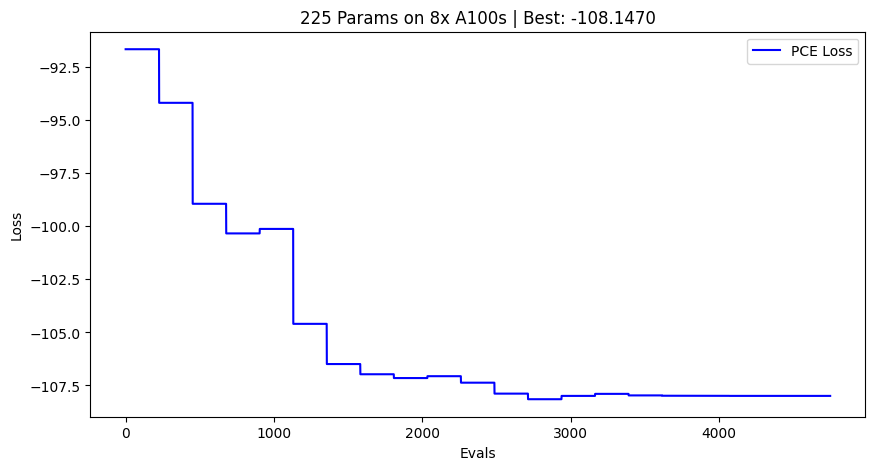

In [ ]:
import cudaq
from cudaq import spin
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import clear_output
import os

# 1. Target the 8x A100 GPUs
cudaq.set_target("nvidia-mqpu")

# 2. Setup Problem Dimensions
num_qubits = 5
num_params = 225
num_paulis = 60
BINARY_CHECKPOINT = "vqe_state.npz"       # For resuming the script
TEXT_EXPORT = "best_parameters.txt"      # Human-readable optimized parameters

# --- KERNEL ---
@cudaq.kernel
def qc_ansatz(n: int, variable_list: list[float], n_layers: int):
    qubits = cudaq.qvector(n)
    for i in range(n):
        h(qubits[i])

    for l in range(n_layers):
        offset = l * 15
        for i in range(n):
            ry(variable_list[offset + i], qubits[i])
            rz(variable_list[offset + 5 + i], qubits[i])
            h(qubits[i])
                
        for i in range(n):
            target = (i + 1) % n
            cx(qubits[i], qubits[target])
            rz(variable_list[offset + 10 + i], qubits[target])
            cx(qubits[i], qubits[target])

# --- HELPERS ---
def get_cudaq_ops(pauli_list):
    ops = []
    for p_str in pauli_list:
        op = spin.identity(5)
        for i, s in enumerate(p_str):
            if s == 'X': op *= spin.x(i)
            elif s == 'Y': op *= spin.y(i)
            elif s == 'Z': op *= spin.z(i)
        ops.append(op)
    return ops

class JengaOptimizer:
    def __init__(self, pauli_ops, n_layers):
        self.pauli_ops = pauli_ops
        self.n_layers = n_layers
        self.loss_history = []
        self.best_loss = float('inf')

    def save_to_text(self, params):
        """Saves parameters as a human-readable text file."""
        header = f"Best Loss: {self.best_loss}\nIteration: {len(self.loss_history)}\nParameters (225 total):"
        np.savetxt(TEXT_EXPORT, params, header=header, footer="End of Parameters")

    def save_checkpoint(self, params):
        """Saves full binary state for resuming."""
        np.savez(BINARY_CHECKPOINT, 
                 params=params, 
                 loss_history=self.loss_history, 
                 best_loss=self.best_loss)

    def load_checkpoint(self):
        if os.path.exists(BINARY_CHECKPOINT):
            data = np.load(BINARY_CHECKPOINT)
            self.loss_history = list(data['loss_history'])
            self.best_loss = data['best_loss']
            print(f"--> Resuming. Best loss found so far: {self.best_loss:.6f}")
            return data['params']
        return None

    def pce_loss(self, params):
        futures = [cudaq.observe_async(qc_ansatz, op, 5, params, self.n_layers) 
                   for op in self.pauli_ops]
        E_list = [f.get().expectation() for f in futures]

        # Tanh Relaxation + Loss Logic
        alpha, beta = 6.0, 15.0
        x_tilde = np.tanh(alpha * np.array(E_list))
        N = len(x_tilde)
        loss = 0.0
        for ell in range(1, N):
            for i in range(N - ell):
                loss += (x_tilde[i] * x_tilde[i+ell])**2
        loss -= beta * np.sum(x_tilde**2)
        
        self.loss_history.append(loss)
        
        # Checkpoint logic
        if loss < self.best_loss:
            self.best_loss = loss
            # Save both formats
            self.save_checkpoint(params)
            self.save_to_text(params)
            print(f"!!! New best loss {loss:.6f} found. Parameters saved to {TEXT_EXPORT}")
        elif len(self.loss_history) % 10 == 0:
            self.save_checkpoint(params)

        self.plot_progress()
        return loss

    def plot_progress(self):
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        plt.plot(self.loss_history, color='blue', label='PCE Loss')
        plt.title(f"225 Params on 8x A100s | Best: {self.best_loss:.4f}")
        plt.xlabel("Evals")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

# --- INITIALIZATION ---
n_layers = 15
pauli_list = []
while len(pauli_list) != num_paulis:
    pauli = ''.join(random.choice(['X', 'Y', 'Z']) for _ in range(5))
    if pauli not in pauli_list: pauli_list.append(pauli)

pauli_ops = get_cudaq_ops(pauli_list)
opt_handler = JengaOptimizer(pauli_ops, n_layers)

# Resume logic
resumed_params = opt_handler.load_checkpoint()
initial_params = resumed_params if resumed_params is not None else np.random.uniform(0, 2*np.pi, 225)

# --- RUN ---
try:
    minimize(opt_handler.pce_loss, initial_params, method='L-BFGS-B', 
             options={'maxiter': 1000, 'disp': True})
except KeyboardInterrupt:
    print("User stopped. Progress is safe.")

In [ ]:
E_list

faster version:

In [ ]:
import cudaq
from cudaq import spin
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import clear_output

# 1. Setup for 8x A100s
cudaq.set_target("nvidia-mqpu")

# 2. Problem Setup
n_paulis = 60
num_qubits = 5

def generate_pauli_list(n, n_qubits):
    pauli_list = []
    while len(pauli_list) != n:
        res = ''.join(random.choice(['X', 'Y', 'Z']) for _ in range(n_qubits))
        if res not in pauli_list:
            pauli_list.append(res)
    
    cudaq_ops = []
    for p_str in pauli_list:
        op = spin.identity(num_qubits)
        for i, char in enumerate(p_str):
            if char == 'X': op *= spin.x(i)
            elif char == 'Y': op *= spin.y(i)
            elif char == 'Z': op *= spin.z(i)
        cudaq_ops.append(op)
    return cudaq_ops

pauli_ops = generate_pauli_list(n_paulis, num_qubits)

# 3. Ansatz Definition
# FIX: Added 'n_layers' as an explicit argument to the kernel
@cudaq.kernel
def labs_ansatz(params: list[float], n: int, n_layers: int):
    qubits = cudaq.qvector(n)
    for i in range(n):
        h(qubits[i])

    for l in range(n_layers):
        offset = 15 * l
        for i in range(n):
            ry(params[offset + i], qubits[i])
            rz(params[offset + 5 + i], qubits[i])
            h(qubits[i])
            
        for i in range(n):
            target = (i + 1) % n
            cx(qubits[i], qubits[target])
            rz(params[offset + 10 + i], qubits[target])
            cx(qubits[i], qubits[target])

# 4. Optimizer Class
class JengaOptimizer:
    def __init__(self, paulis, n_qubits, n_layers):
        self.paulis = paulis
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.loss_history = []

    def compute_loss(self, params):
        # FIX: Pass self.n_layers to the observe_async call
        futures = [cudaq.observe_async(labs_ansatz, p_op, params, self.n_qubits, self.n_layers) 
                   for p_op in self.paulis]
        
        E_list = [f.get().expectation() for f in futures]
        
        alpha, beta = 6.0, 15.0
        x_tilde = np.tanh(alpha * np.array(E_list))
        
        N = len(x_tilde)
        loss = 0.0
        for ell in range(1, N):
            for i in range(N - ell):
                loss += (x_tilde[i] * x_tilde[i+ell])**2
        
        loss -= beta * np.sum(x_tilde**2)
        
        self.loss_history.append(loss)
        self.plot_progress()
        return loss

    def plot_progress(self):
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        plt.plot(self.loss_history, color='tab:red', label='Jenga Loss')
        plt.title(f"8x A100 Optimization | {self.n_layers*15} Params | Iteration {len(self.loss_history)}")
        plt.xlabel("Function Evaluations")
        plt.ylabel("Loss")
        plt.grid(True, alpha=0.2)
        plt.legend()
        plt.show()

# 5. Initialization and Execution
n_layers = 15 
num_total_params = n_layers * 15

# Initial parameters between 0 and 2pi
initial_params = np.random.uniform(0, 2 * np.pi, num_total_params)

# Pass n_layers into the class so it can be sent to the kernel
opt = JengaOptimizer(pauli_ops, num_qubits, n_layers)

print(f"Starting L-BFGS-B Optimizer with {num_total_params} parameters...")

res = minimize(
    opt.compute_loss,
    initial_params,
    method='L-BFGS-B',
    options={
        'maxiter': 1200,   # large upper bound on iterations
        'maxfun': 1200,      # stop after ~2000 function evaluations
        'ftol': 0.0,         # or very small, e.g. 1e-12, to avoid early ftol stop
        'disp': True
    }
)

print(f"Optimization Finished!")
print(f"Final Optimized Loss: {res.fun}")

In [ ]:
np.savez(
    "jenga_state.npz",
    best_params=res.x,
    final_loss=res.fun,
    loss_history=np.array(opt.loss_history),
    n_layers=n_layers,
    n_qubits=num_qubits,
    pauli_strings=np.array([str(p) for p in pauli_ops], dtype=object)
)

print("State saved to jenga_state.npz")

safer version:


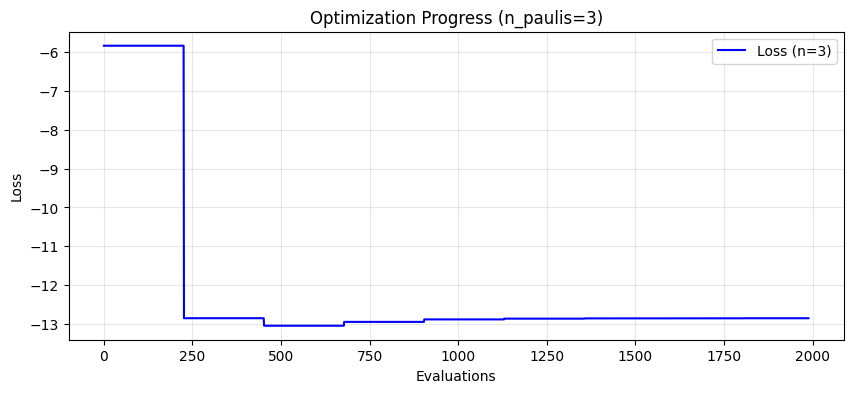

In [ ]:
import cudaq
from cudaq import spin
import numpy as np
import random
import time
import pandas as pd
import os
import heapq
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import clear_output

# --- CONFIGURATION ---
cudaq.set_target("nvidia-mqpu")  # Parallelize across 8 A100s
NUM_QUBITS = 5
N_LAYERS = 15
NUM_PARAMS = N_LAYERS * 15      # 225
PARAMS_FILE = "params_results.csv"
EVALUES_FILE = "evalues_results.csv"
TIMING_FILE = "timing_log.csv"

# --- KERNEL DEFINITION ---
@cudaq.kernel
def labs_ansatz(params: list[float], n: int, n_layers: int):
    qubits = cudaq.qvector(n)
    for i in range(n):
        h(qubits[i])

    for l in range(n_layers):
        offset = 15 * l
        for i in range(n):
            ry(params[offset + i], qubits[i])
            rz(params[offset + 5 + i], qubits[i])
            h(qubits[i])
            
        for i in range(n):
            target = (i + 1) % n
            cx(qubits[i], qubits[target])
            rz(params[offset + 10 + i], qubits[target])
            cx(qubits[i], qubits[target])

# --- HELPER FUNCTIONS ---
def generate_pauli_list(n, n_qubits):
    pauli_strings = []
    while len(pauli_strings) < n:
        res = ''.join(random.choice(['X', 'Y', 'Z']) for _ in range(n_qubits))
        if res not in pauli_strings:
            pauli_strings.append(res)
    
    cudaq_ops = []
    for p_str in pauli_strings:
        op = spin.identity(n_qubits)
        for i, char in enumerate(p_str):
            if char == 'X': op *= spin.x(i)
            elif char == 'Y': op *= spin.y(i)
            elif char == 'Z': op *= spin.z(i)
        cudaq_ops.append(op)
    return cudaq_ops

class JengaOptimizer:
    def __init__(self, paulis, n_paulis):
        self.paulis = paulis
        self.n_paulis = n_paulis
        self.alpha = 6.0
        self.beta = 15.0
        self.history = []
        # Store top 100 as: (-loss, params, e_list) for max-heap behavior (keep smallest losses)
        self.top_100 = [] 

    def get_e_list(self, params):
        # mqpu target parallelizes these async calls across the 8 A100s
        futures = [cudaq.observe_async(labs_ansatz, p_op, params, NUM_QUBITS, N_LAYERS) 
                   for p_op in self.paulis]
        return np.array([f.get().expectation() for f in futures])

    def loss_func(self, params):
        E_list = self.get_e_list(params)
        x_tilde = np.tanh(self.alpha * E_list)
        N = len(x_tilde)
        
        loss = 0.0
        for ell in range(1, N):
            for i in range(N - ell):
                loss += (x_tilde[i] * x_tilde[i+ell])**2
        loss -= self.beta * np.sum(x_tilde**2)
        
        self.history.append(loss)
        
        # Tracking top 100 runs
        # Use negative loss because heapq is a min-heap; we want to replace the LARGEST (worst) loss in our top 100 list
        entry = (-loss, list(params), list(E_list))
        if len(self.top_100) < 100:
            heapq.heappush(self.top_100, entry)
        elif -loss > self.top_100[0][0]:
            heapq.heapreplace(self.top_100, entry)
            
        self.plot_realtime()
        return loss

    def plot_realtime(self):
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        plt.plot(self.history, label=f"Loss (n={self.n_paulis})", color='blue')
        plt.xlabel("Evaluations")
        plt.ylabel("Loss")
        plt.title(f"Optimization Progress (n_paulis={self.n_paulis})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# --- INITIALIZE CSV FILES ---
def init_files():
    if not os.path.exists(PARAMS_FILE):
        pd.DataFrame(columns=['n_paulis', 'rank', 'loss'] + [f'p{i}' for i in range(NUM_PARAMS)]).to_csv(PARAMS_FILE, index=False)
    if not os.path.exists(EVALUES_FILE):
        pd.DataFrame(columns=['n_paulis', 'rank', 'loss'] + [f'e{i}' for i in range(60)]).to_csv(EVALUES_FILE, index=False)
    if not os.path.exists(TIMING_FILE):
        pd.DataFrame(columns=['n_paulis', 'best_loss', 'duration_sec']).to_csv(TIMING_FILE, index=False)

init_files()

# --- MAIN LOOP ---
for n_paulis in range(3, 61):
    print(f"Starting n_paulis = {n_paulis}...")
    pauli_ops = generate_pauli_list(n_paulis, NUM_QUBITS)
    optimizer = JengaOptimizer(pauli_ops, n_paulis)
    
    initial_params = np.random.uniform(0, 2 * np.pi, NUM_PARAMS)
    start_time = time.time()
    
    res = minimize(
        optimizer.loss_func,
        initial_params,
        method='L-BFGS-B',
        options={'maxiter': 500, 'maxfun': 500}
    )
    
    duration = time.time() - start_time
    best_loss = res.fun
    
    # --- LOG TIMING & BEST LOSS ---
    timing_data = pd.DataFrame([[n_paulis, best_loss, duration]])
    timing_data.to_csv(TIMING_FILE, mode='a', header=False, index=False)
    
    # --- SAVE TOP 100 TRACKED RUNS ---
    # Sort by loss (ascending)
    top_results = sorted(optimizer.top_100, key=lambda x: -x[0])
    
    p_rows, e_rows = [], []
    for rank, (neg_loss, params, e_list) in enumerate(top_results):
        loss = -neg_loss
        # Prepare e-list (binarized or raw) - user asked for e-values.
        # Binarize for output as requested: 1 if >= 0, -1 if < 0
        e_bin = [1 if e >= 0 else -1 for e in e_list]
        e_padded = e_bin + [0] * (60 - len(e_bin)) # Pad to 60 columns
        
        p_rows.append([n_paulis, rank+1, loss] + params)
        e_rows.append([n_paulis, rank+1, loss] + e_padded)
        
    pd.DataFrame(p_rows).to_csv(PARAMS_FILE, mode='a', header=False, index=False)
    pd.DataFrame(e_rows).to_csv(EVALUES_FILE, mode='a', header=False, index=False)

print("Batch optimization complete.")

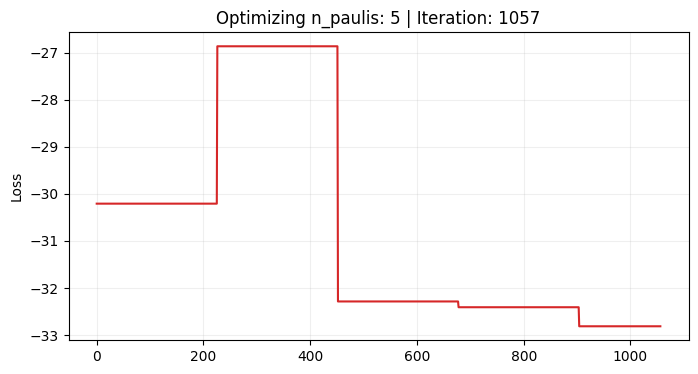

In [ ]:
import cudaq
from cudaq import spin
import numpy as np
import random
import time
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import clear_output

# --- CONFIGURATION ---
cudaq.set_target("nvidia-mqpu")  # Use 8x A100s
NUM_QUBITS = 5
N_LAYERS = 15
NUM_PARAMS = N_LAYERS * 15      # 225
CSV_FILE = "optimization_log.csv"

# --- KERNEL DEFINITION ---
@cudaq.kernel
def labs_ansatz(params: list[float], n: int, n_layers: int):
    qubits = cudaq.qvector(n)
    # Initial Superposition
    for i in range(n):
        h(qubits[i])

    for l in range(n_layers):
        offset = 15 * l
        for i in range(n):
            ry(params[offset + i], qubits[i])
            rz(params[offset + 5 + i], qubits[i])
            h(qubits[i])
            
        for i in range(n):
            target = (i + 1) % n
            cx(qubits[i], qubits[target])
            rz(params[offset + 10 + i], qubits[target])
            cx(qubits[i], qubits[target])

# --- HELPERS ---
def generate_pauli_list(n, n_qubits):
    pauli_list = []
    while len(pauli_list) < n:
        res = ''.join(random.choice(['X', 'Y', 'Z']) for _ in range(n_qubits))
        if res not in pauli_list:
            pauli_list.append(res)
    
    cudaq_ops = []
    for p_str in pauli_list:
        op = spin.identity(n_qubits)
        for i, char in enumerate(p_str):
            if char == 'X': op *= spin.x(i)
            elif char == 'Y': op *= spin.y(i)
            elif char == 'Z': op *= spin.z(i)
        cudaq_ops.append(op)
    return cudaq_ops

def export_to_bin(top_bitstrings, n_qubits, n_paulis):
    """Saves Top 128 strings into the specific 8192x512 int8 format."""
    filename = f"warm_start_pauli_{n_paulis}.bin"
    gpu_pop_size = 8192
    gpu_max_n = 512
    
    # Initialize with random noise as per requirements
    host_buffer = np.random.choice([-1, 1], size=(gpu_pop_size, gpu_max_n)).astype(np.int8)
    
    # Fill the top portion with our quantum results
    for i, s in enumerate(top_bitstrings[:128]): # Top 128
        arr = np.array([int(b) for b in s])
        pm1 = (2 * arr - 1).astype(np.int8) # Convert 0/1 to -1/1
        host_buffer[i, :n_qubits] = pm1
        
    host_buffer.tofile(filename)
    print(f"--> Exported binary: {filename}")

class JengaOptimizer:
    def __init__(self, paulis, n_qubits, n_layers):
        self.paulis = paulis
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.loss_history = []
        self.alpha, self.beta = 6.0, 15.0

    def compute_loss(self, params):
        # Async distribution across all 8 GPUs
        futures = [cudaq.observe_async(labs_ansatz, p_op, params, self.n_qubits, self.n_layers) 
                   for p_op in self.paulis]
        
        E_list = np.array([f.get().expectation() for f in futures])
        x_tilde = np.tanh(self.alpha * E_list)
        
        N = len(x_tilde)
        loss = 0.0
        for ell in range(1, N):
            for i in range(N - ell):
                loss += (x_tilde[i] * x_tilde[i+ell])**2
        loss -= self.beta * np.sum(x_tilde**2)
        
        self.loss_history.append(loss)
        self.plot_progress()
        return loss

    def plot_progress(self):
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        plt.plot(self.loss_history, color='tab:red')
        plt.title(f"Optimizing n_paulis: {len(self.paulis)} | Iteration: {len(self.loss_history)}")
        plt.ylabel("Loss")
        plt.grid(True, alpha=0.2)
        plt.show()

# --- MAIN LOOP ---

# Initialize CSV
if not os.path.exists(CSV_FILE):
    headers = ['n_paulis', 'duration', 'best_loss'] + [f'p{i}' for i in range(NUM_PARAMS)]
    pd.DataFrame(columns=headers).to_csv(CSV_FILE, index=False)

for n_p in range(3, 61):
    print(f"\n>>> STARTING RUN: {n_p} PAULI STRINGS")
    pauli_ops = generate_pauli_list(n_p, NUM_QUBITS)
    opt = JengaOptimizer(pauli_ops, NUM_QUBITS, N_LAYERS)
    
    start_time = time.time()
    initial_params = np.random.uniform(0, 2 * np.pi, NUM_PARAMS)
    
    # 1. Run Optimization
    res = minimize(
        opt.compute_loss,
        initial_params,
        method='L-BFGS-B',
        options={'maxiter': 1500, 'maxfun': 1500, 'ftol': 1e-6}
    )
    
    elapsed = time.time() - start_time
    
    # 2. Extract Top 128 Strings (Sampling the optimized circuit)
    print("Sampling optimized circuit for bitstrings...")
    sample_result = cudaq.sample(labs_ansatz, res.x, NUM_QUBITS, N_LAYERS, shots_count=5000)
    # Sort results by frequency
    sorted_strings = [bs for bs, count in sorted(sample_result.items(), key=lambda x: x[1], reverse=True)]
    
    # 3. Save Binary File
    export_to_bin(sorted_strings, NUM_QUBITS, n_p)
    
    # 4. Save CSV Log
    log_data = [n_p, elapsed, res.fun] + list(res.x)
    pd.DataFrame([log_data]).to_csv(CSV_FILE, mode='a', header=False, index=False)
    
    print(f"Run {n_p} Complete. Loss: {res.fun:.4f} Time: {elapsed:.2f}s")

print("\nAll tasks completed successfully.")